# Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Fetch Solar & Wind FCST Generation

In [2]:
# Location
country_capital = "Madrid"
country_code = "ES"


# Period
today = pd.Timestamp.now(
    tz=f"Europe/{country_capital}"
).normalize()

yesterday=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=1)
)
last_week=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=7)
)

tomorrow =(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    + pd.Timedelta(days=1)
)

start=last_week
end=today


# ENTSOE Client
df = entsoe_client.query_wind_and_solar_forecast(
    country_code=country_code,
    start=last_week,
    end=today)

# EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-09-04 00:00:00+02:00 to 2026-09-10 23:45:00+02:00
Freq: 15min
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Solar         672 non-null    float64
 1   Wind Onshore  672 non-null    float64
dtypes: float64(2)
memory usage: 15.8 KB


In [4]:
df.head()

,Solar,Wind Onshore
2026-09-04 00:00:00+02:00,468.0,2132.0
2026-09-04 00:15:00+02:00,457.0,2093.0
2026-09-04 00:30:00+02:00,448.0,2052.0
2026-09-04 00:45:00+02:00,441.0,2013.0
2026-09-04 01:00:00+02:00,434.0,1976.0


In [5]:
df.columns

Index(['Solar', 'Wind Onshore'], dtype='str')

In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Solar,672.0,9044.90,9908.03,19.0,224.75,2127.5,20377.25,25746.0
Wind Onshore,672.0,4603.96,2931.55,682.0,2465.75,3642.0,6421.50,11513.0


In [7]:
# Check that timestamps are unique
assert df.index.is_unique

# Check that timestamps are sorted
assert df.index.is_monotonic_increasing

In [8]:
df_mwh = df.copy()

for col in df_mwh.columns:
    df_mwh[col]*= 0.25

df_mwh.head()

,Solar,Wind Onshore
2026-09-04 00:00:00+02:00,117.00,533.00
2026-09-04 00:15:00+02:00,114.25,523.25
2026-09-04 00:30:00+02:00,112.00,513.00
2026-09-04 00:45:00+02:00,110.25,503.25
2026-09-04 01:00:00+02:00,108.50,494.00


In [9]:
df_mwh.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Solar,672.0,2261.23,2477.01,4.75,56.19,531.88,5094.31,6436.50
Wind Onshore,672.0,1150.99,732.89,170.50,616.44,910.50,1605.38,2878.25


In [10]:
generation_per_day = pd.pivot_table(
    df_mwh,
    values=["Solar", "Wind Onshore"],
    index=df_mwh.index.date,
    aggfunc="sum"
) 

print(generation_per_day.round(2))

                Solar  Wind Onshore
2026-09-04  232500.00      56177.25
2026-09-05  185819.00     123605.75
2026-09-06  203942.50      72638.50
2026-09-07  233151.75      59696.25
2026-09-08  220488.75     129709.25
2026-09-09  207398.25     232403.25
2026-09-10  236243.50      99234.25


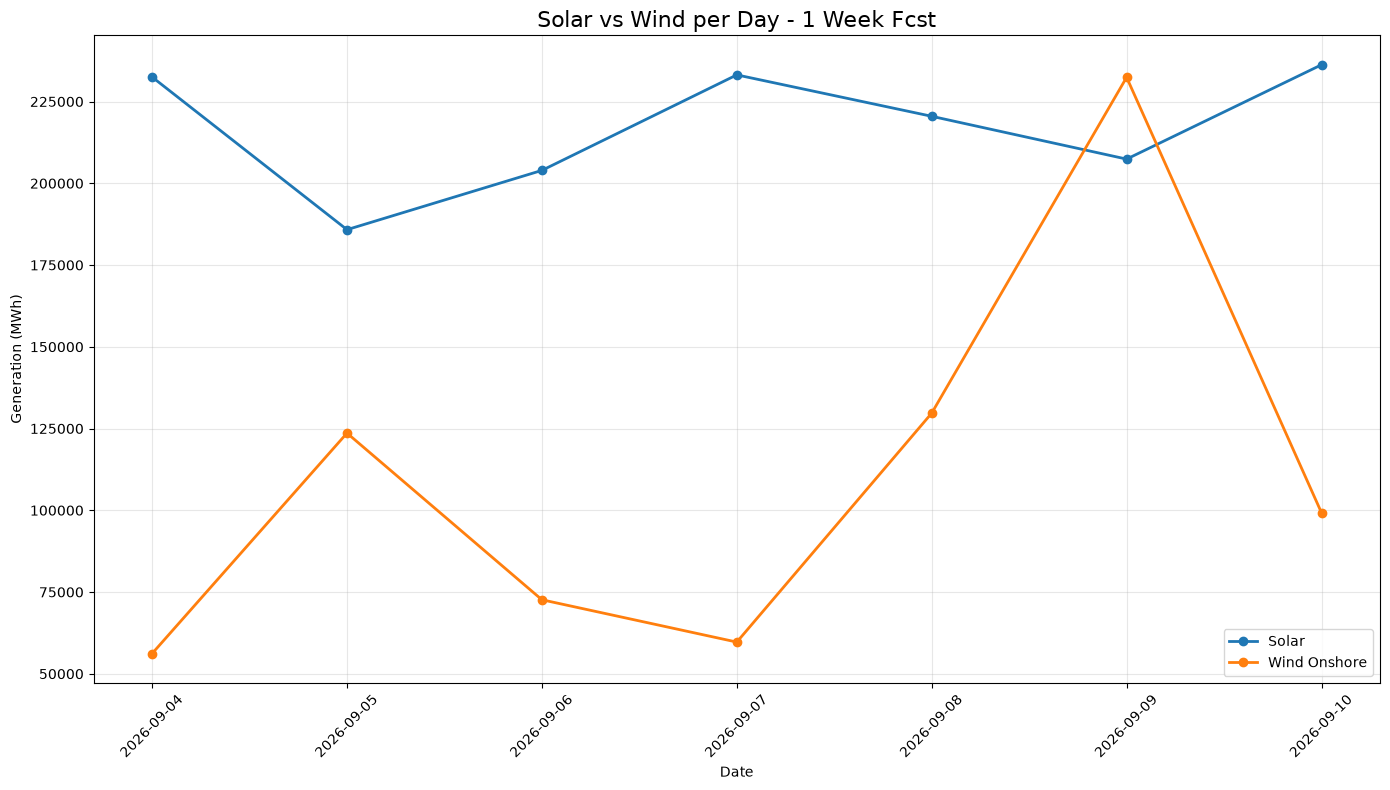

In [11]:
# Plot \Solar vs Wind per Day - 1 Week Fcst/

fig, ax = plt.subplots(figsize=(14, 8))

for col in generation_per_day.columns:
    ax.plot(
        generation_per_day.index,
        generation_per_day[col],
        marker="o",
        linewidth=2,
        label=col
    )


plt.title("Solar vs Wind per Day - 1 Week Fcst", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Generation (MWh)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

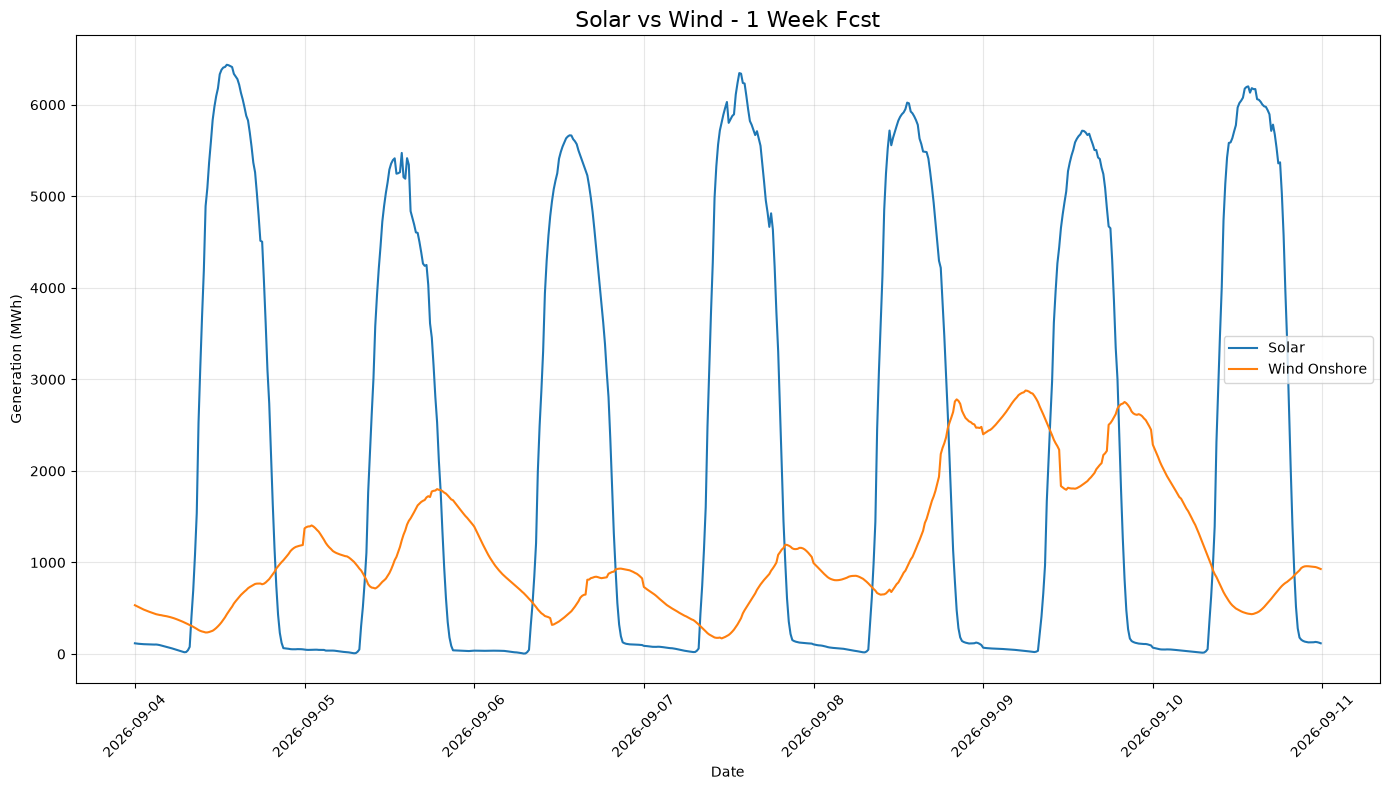

In [12]:
# Plot \Solar vs Wind - 1 Week Fcst/

fig, ax = plt.subplots(figsize=(14, 8))

for col in df_mwh.columns:
    ax.plot(
        df_mwh.index,
        df_mwh[col],
        linewidth=1.5,
        label=col
    )

plt.title("Solar vs Wind - 1 Week Fcst", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Generation (MWh)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()